In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('corona_tested_individuals_ver_006.english.csv')


/tmp/ipykernel_44542/4164438771.py:6: DtypeWarning: Columns (0: age_60_and_above) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('corona_tested_individuals_ver_006.english.csv')


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   test_date            278848 non-null  datetime64[us]
 1   cough                278596 non-null  float64       
 2   fever                278596 non-null  float64       
 3   sore_throat          278847 non-null  float64       
 4   shortness_of_breath  278847 non-null  float64       
 5   head_ache            278847 non-null  float64       
 6   corona_result        278848 non-null  str           
 7   age_60_and_above     151528 non-null  str           
 8   gender               259285 non-null  str           
 9   test_indication      278848 non-null  str           
dtypes: datetime64[us](1), float64(5), str(4)
memory usage: 21.3 MB


In [2]:
#EDA
print(df.head())

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMNS ==========")
print(df.columns)

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

    test_date  cough  fever  sore_throat  shortness_of_breath  head_ache  \
0  2020-04-30    0.0    0.0          0.0                  0.0        0.0   
1  2020-04-30    1.0    0.0          0.0                  0.0        0.0   
2  2020-04-30    0.0    1.0          0.0                  0.0        0.0   
3  2020-04-30    1.0    0.0          0.0                  0.0        0.0   
4  2020-04-30    1.0    0.0          0.0                  0.0        0.0   

  corona_result age_60_and_above  gender test_indication  
0      negative              NaN  female           Other  
1      negative              NaN  female           Other  
2      negative              NaN    male           Other  
3      negative              NaN  female           Other  
4      negative              NaN    male           Other  

========== DATASET SHAPE ==========
(278848, 10)

========== COLUMNS ==========
Index(['test_date', 'cough', 'fever', 'sore_throat', 'shortness_of_breath',
       'head_ache', 'corona_resu

In [ ]:
#Date

df['test_date'] = pd.to_datetime(df['test_date'])

df.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [ ]:
#Age

df['age_60_and_above'].value_counts(dropna=False)

age_60_and_above
NaN    127320
No     125703
Yes     25825
Name: count, dtype: int64

In [17]:
df['age_60_and_above'].value_counts(dropna=False, normalize=True) * 100

age_60_and_above
Missing    45.659284
No         45.079398
Yes         9.261318
Name: proportion, dtype: float64

In [12]:
pd.crosstab(
    df['age_60_and_above'].fillna('Missing'),
    df['corona_result']
)

corona_result,negative,other,positive
age_60_and_above,,,
Missing,122404,1656,3260
No,114602,1836,9265
Yes,23221,400,2204


In [13]:
df['age_60_and_above'] = (
    df['age_60_and_above']
    .fillna('Missing')
)

In [19]:
#Gender
 
df['gender'].value_counts(dropna=False)

gender
female     130158
male       129127
Missing     19563
Name: count, dtype: int64

In [16]:
df['gender'].value_counts(dropna=False, normalize=True) * 100

gender
female     46.677043
male       46.307307
Missing     7.015650
Name: proportion, dtype: float64

In [15]:
df['gender'] = df['gender'].fillna('Missing')

In [ ]:
#Test Results

df['corona_result'].value_counts(dropna=False)

corona_result
negative    260227
positive     14729
other         3892
Name: count, dtype: int64

In [21]:
df['corona_result'].value_counts(normalize=True) * 100

corona_result
negative    93.322168
positive     5.282089
other        1.395742
Name: proportion, dtype: float64

In [22]:
#Test indication?

df['test_indication'].value_counts()


test_indication
Other                     242741
Abroad                     25468
Contact with confirmed     10639
Name: count, dtype: int64

In [23]:
pd.crosstab(
    df['test_indication'],
    df['corona_result'],
    normalize='index'
) * 100

corona_result,negative,other,positive
test_indication,,,
Abroad,91.114340,1.547039,7.338621
Contact with confirmed,29.702040,1.513300,68.784660
Other,96.342192,1.374716,2.283092


In [24]:
#Symptons vs results

pd.crosstab(
    df['cough'],
    df['corona_result'],
    normalize='index'
) * 100


corona_result,negative,other,positive
cough,,,
0.0,95.199435,1.368629,3.431937
1.0,82.852610,1.555840,15.591551


In [30]:
pd.crosstab(
    df['fever'],
    df['corona_result'],
    normalize='index'
) * 100



corona_result,negative,other,positive
fever,,,
0.0,95.074053,1.368535,3.557412
1.0,72.710555,1.733174,25.556271


In [31]:
pd.crosstab(
    df['sore_throat'],
    df['corona_result'],
    normalize='index'
) * 100



corona_result,negative,other,positive
sore_throat,,,
0.0,93.839398,1.393177,4.767425
1.0,19.003115,1.765317,79.231568


In [32]:
pd.crosstab(
    df['shortness_of_breath'],
    df['corona_result'],
    normalize='index'
) * 100



corona_result,negative,other,positive
shortness_of_breath,,,
0.0,93.714430,1.393587,4.891983
1.0,24.413443,1.775523,73.811034


In [33]:
pd.crosstab(
    df['head_ache'],
    df['corona_result'],
    normalize='index'
) * 100




corona_result,negative,other,positive
head_ache,,,
0.0,94.083919,1.396722,4.519359
1.0,6.130903,1.284176,92.584921


In [34]:
pd.crosstab(
    df['head_ache'],
    df['corona_result'],
    normalize='index'
) * 100


corona_result,negative,other,positive
head_ache,,,
0.0,94.083919,1.396722,4.519359
1.0,6.130903,1.284176,92.584921


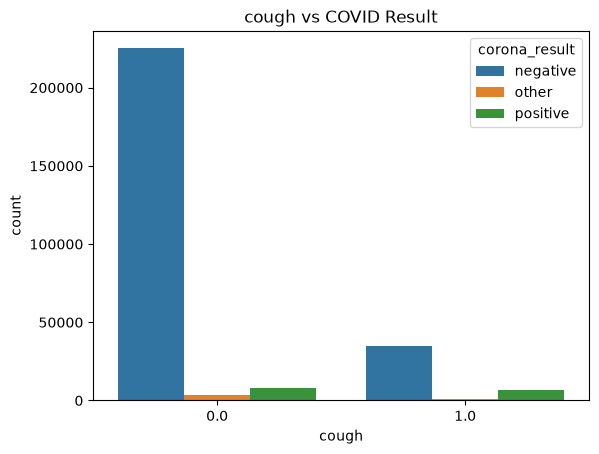

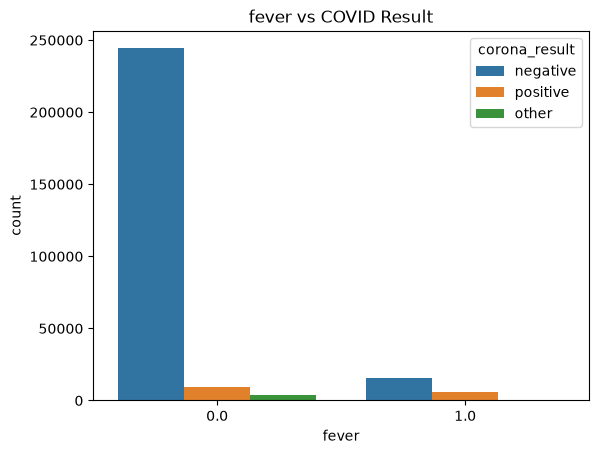

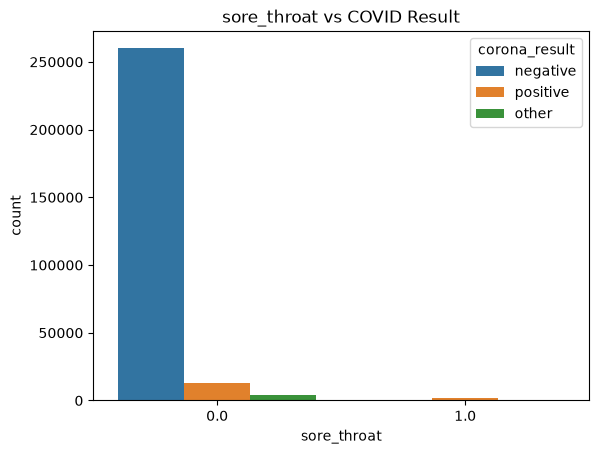

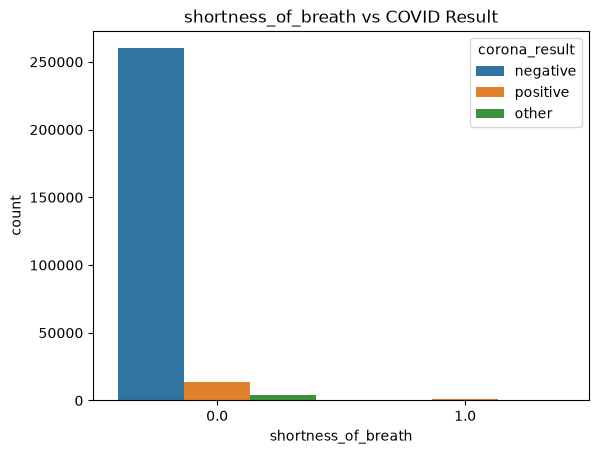

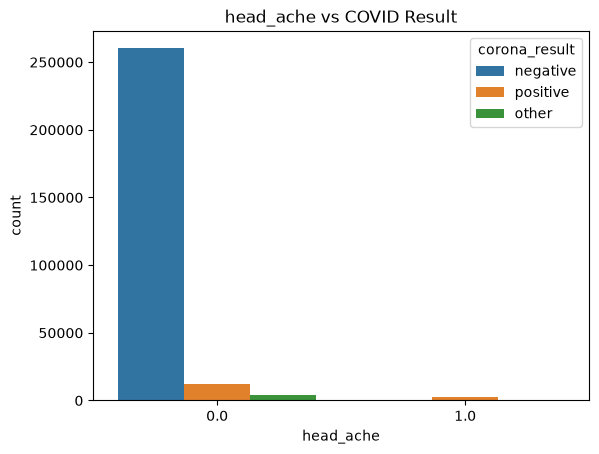

In [35]:
symptoms = [
    'cough',
    'fever',
    'sore_throat',
    'shortness_of_breath',
    'head_ache'
]

for symptom in symptoms:
    sns.countplot(
        x=symptom,
        hue='corona_result',
        data=df
    )

    plt.title(f'{symptom} vs COVID Result')
    plt.show()

In [36]:
symptoms = [
    'cough',
    'fever',
    'sore_throat',
    'shortness_of_breath',
    'head_ache'
]

for symptom in symptoms:

    positive_rate = (
        df[df[symptom] == 1]
        ['corona_result']
        .eq('positive')
        .mean() * 100
    )

    print(f"{symptom}: {positive_rate:.1f}% positive")

cough: 15.6% positive
fever: 25.6% positive
sore_throat: 79.2% positive
shortness_of_breath: 73.8% positive
head_ache: 92.6% positive


In [37]:
df[
    [
        'cough',
        'fever',
        'sore_throat',
        'shortness_of_breath',
        'head_ache'
    ]
].corr()

,cough,fever,sore_throat,shortness_of_breath,head_ache
cough,1.000000,0.454358,0.115808,0.106891,0.116485
fever,0.454358,1.000000,0.122948,0.126216,0.169099
sore_throat,0.115808,0.122948,1.000000,0.197540,0.323132
shortness_of_breath,0.106891,0.126216,0.197540,1.000000,0.202538
head_ache,0.116485,0.169099,0.323132,0.202538,1.000000
